In [1]:
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn import pipeline
from rdkit import Chem
import pandas as pd
import numpy as np
import sklearn
import scipy

In [ ]:
def make_pipeline(model):
    return pipeline.Pipeline([
        ("transform", PowerTransformer(method='yeo-johnson', standardize=False)),
        ("scale", RobustScaler()),
        ("predict", model)
    ])

In [3]:
rng = np.random.default_rng(seed=58)

In [4]:
df = pd.read_csv("data/processed_dataset_wo_metals.csv")

In [5]:
df[df["id"] == 769]

,smiles,id,energy,atomization_energy,homo_lumo_gap,ionization_energy,electron_affinity,chemical_potential,molecular_dipole_norm,molecular_quadrupole_principal_invariant_2,...,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,canon_smiles,solubility
7359,[O:1]=[Si:2]=[O:3],769,-9.967178,0.856912,0.289216,0.661165,0.053468,-0.349428,0.002137,-73.021889,...,0,0,0,0,0,0,0,0,O=[Si]=O,-3.602668


In [29]:
df[["avg_atomic_dipole_norm", "molecular_dipole_norm"]]

,avg_atomic_dipole_norm,molecular_dipole_norm
0,0.091638,1.513984
1,0.105602,0.965182
2,0.132485,0.909688
3,0.123096,5.103982
4,0.136925,2.145071
...,...,...
8758,0.110348,0.635633
8759,0.136620,1.863283
8760,0.090201,0.372170
8761,0.119540,0.956828


In [21]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1) # , "avg_atomic_quadrupole_principal_invariant_3", "molecular_quadrupole_principal_invariant_3"

In [22]:
X = X.drop([7359]) # , 587

In [15]:
X_wo_atom = X.drop(["avg_atomic_quadrupole_principal_invariant_3"], axis=1)

In [9]:
df[["id", "avg_atomic_quadrupole_principal_invariant_3"]].nlargest(10, columns="avg_atomic_quadrupole_principal_invariant_3")

,id,avg_atomic_quadrupole_principal_invariant_3
7359,769,14.471934
5357,5884,0.230704
8171,842,0.200549
1825,2685,0.156272
1826,2686,0.079830
5993,6456,0.077964
7172,7520,0.075170
3661,4347,0.071856
1406,2289,0.069148
2841,3603,0.060347


In [10]:
df[["id", "molecular_quadrupole_principal_invariant_3"]].nlargest(10, columns="molecular_quadrupole_principal_invariant_3")

,id,molecular_quadrupole_principal_invariant_3
587,1539,1.561343e+09
1657,2529,1.543235e+08
3949,4610,7.055779e+07
96,1088,4.600046e+07
6969,7337,4.160781e+07
1590,2465,3.977570e+07
2999,3748,3.447213e+07
2997,3746,3.447213e+07
7001,7367,3.429472e+07
7012,7376,2.534992e+07


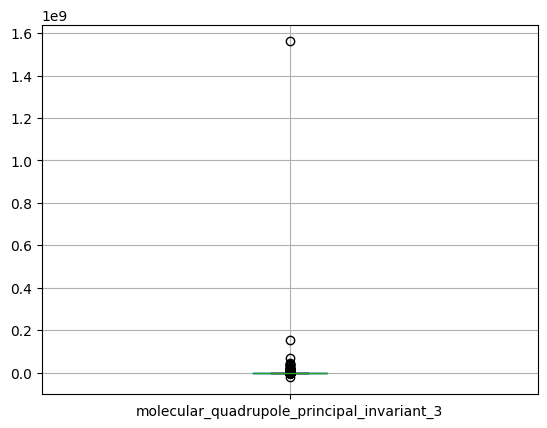

In [14]:
X.boxplot("molecular_quadrupole_principal_invariant_3")
plt.show()

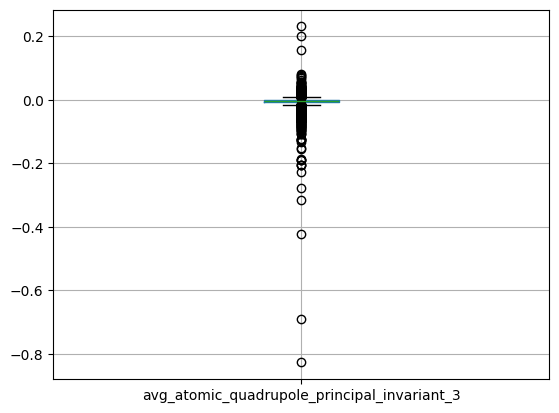

In [15]:
X.boxplot("avg_atomic_quadrupole_principal_invariant_3")
plt.show()

In [19]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
pl = make_pipeline(sklearn.linear_model.LinearRegression())

In [28]:
for i, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    pl.fit(X_train, y_train)
    y_pred = pl.predict(X_test)

    
    print(f"Fold {i+1} R²:", r2_score(y_test, y_pred))

    coefs = pl["predict"].coef_

    sort = np.argsort(np.abs(coefs))
    
    for coef, feature in zip(coefs[sort[::-1]], df.columns[sort[::-1]], strict=True):
        print(feature, coef)
    
    print("\n\n")

Fold 1 R²: 0.7383942624622595
avg_atomic_quadrupole_principal_invariant_2 -3828007.9428481585
avg_atomic_dipole_norm 3828006.025198895
avg_atomic_sasa 2455.264884447019
avg_partial_charge_cyclohexane -1728.5392120891781
ir_norm_intensity_2750_4000 -1510.788674897114
avg_atomic_fukui_minus 388.7909466023875
ir_centroid_freq_2750_4000 376.8388608826351
fr_bicyclic 190.12068580215416
fr_tetrazole 139.50319116910072
fr_aryl_methyl -134.2753870164256
fr_barbitur 128.5398182174875
fr_Ndealkylation2 102.25128848538674
fr_nitro_arom -90.06121330034145
fr_halogen -80.70819273377272
fr_aniline 75.41103256645653
fr_sulfone 63.46127963364275
EState_VSA1 -62.632475922922566
fr_sulfonamd -59.64882179934294
fr_prisulfonamd 53.02449130383485
solvation_energy_thf 49.60273263348593
fr_imide -46.823874174811024
fr_lactone 41.615953474282584
sterimol_Bmax -39.6625522186893
fr_piperdine -36.73482760504401
fr_sulfide -34.10400748068519
fr_C_O_noCOO 34.04611746936594
fr_C_S -33.99041300135615
fr_imidazole -3